# Spatial MSAA

In [1]:
%matplotlib inline

In [2]:
#imports 
import warnings
import os
import pandas as pd
import seaborn as sns
import numpy as np
import networkx as netx
import pywt
import matplotlib.pyplot as plt
import matplotlib.style as style
import matplotlib.cm as cm
from scipy.io import loadmat
from scipy.spatial.distance import cdist
import scipy
from sklearn.manifold import LocallyLinearEmbedding
import nilearn as nl             # pip: nilearn==0.10.0
from nilearn.maskers import NiftiMasker
import nibabel as nib
import nltools as nlt
from matplotlib.colors import ListedColormap
from sklearn.metrics import pairwise_distances
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, leaves_list, fcluster, leaves_list
from scipy.spatial.distance import cdist
from itertools import compress
from scipy.optimize import minimize
import sys, pathlib, importlib.util
import time



In [3]:
sys.path.insert(0, str(pathlib.Path('hypertools').resolve()))

spec = importlib.util.spec_from_file_location('normalize', 'hypertools/normalize.py')
ht = importlib.util.module_from_spec(spec)
spec.loader.exec_module(ht)

sys.path.append("helpers")

from MultiSubject_AA import Subject, multi_subject_aa 

In [4]:
def rank_archetypes_by_strength(all_results, cond):
    """
    Computes average L2-norm (energy) of each archetype across subjects.
    Returns sorted indices and scores.
    """
    subj_results = all_results[cond]["results_subj"]
    noc = subj_results[0]["S"].shape[0]

    # accumulate average energy per archetype
    scores = np.zeros(noc)
    for subj in subj_results:
        S = subj["S"]  # shape (noc, V)
        scores += np.mean(S**2, axis=1)  # mean power per archetype

    scores /= len(subj_results)
    ranked_idx = np.argsort(scores)[::-1]  # descending order
    return ranked_idx, scores


# Test with our *actual* data

In [5]:
def array_cutter(data_list, cut_length): 
    data_list_new = data_list
    for subject in range(len(data_list)):
        data_list_new[subject] = data_list_new[subject][:-cut_length]
    return data_list_new

In [6]:
# test with real data
pieman_name = 'data/pieman/raw/pieman_data.mat'
pieman_data = loadmat(pieman_name)
pieman_conds = ['intact', 'paragraph', 'word', 'rest']

posterior = loadmat('data/pieman/raw/pieman_posterior_K700.mat')
centers = posterior['posterior']['centers'][0][0][0][0][0]
widths = np.array(list(posterior['posterior']['widths'][0][0][0][0][0][:, 0].T))

data = []
conds = []
for c in pieman_conds:
    if c == 'paragraph':
        next_data = list(map(lambda i: pieman_data[c][:, i][0], np.where(np.arange(pieman_data[c].shape[1]) != 3)[0]))
    else:
        next_data = list(map(lambda i: pieman_data[c][:, i][0], np.arange(pieman_data[c].shape[1])))
    data.extend(next_data)
    conds.extend([c]*len(next_data))

In [7]:
conds_array = np.array(conds)
intact_list = [data[i] for i in np.where(conds_array=='intact')[0]]
paragraph_list = [data[i] for i in np.where(conds_array=='paragraph')[0]]
word_list = [data[i] for i in np.where(conds_array=='word')[0]]
rest_list = [data[i] for i in np.where(conds_array=='rest')[0]]

In [8]:
# run this if you want to cut last 100 timepoints off of rest
rest_list = array_cutter(rest_list, 100)

In [9]:
# data groups
intact_data_normalized = ht.normalize(intact_list, normalize = 'across')
paragraph_data_normalized = ht.normalize(paragraph_list, normalize = 'across')
word_data_normalized = ht.normalize(word_list, normalize = 'across')
rest_data_normalized = ht.normalize(rest_list, normalize = 'across')

In [10]:
def coerce_TxV(x):
    x = np.asarray(x)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D array, got {x.shape}")
    # We want T x V. If looks like V x T (V >> T), transpose it.
    T, V = x.shape
    if V < T:
        x = x.T  # now T x V
        T, V = x.shape
    # zero-mean per voxel (column) across time
    x = x - x.mean(axis=0, keepdims=True)
    return x.astype(np.float32, copy=False)

In [11]:
# neuroimaging fxn's
def nii2cmu(nifti_file, mask_file=None):
    '''
    inputs:
      nifti_file: a filename of a .nii or .nii.gz file to be converted into
                  CMU format

      mask_file: a filename of a .nii or .nii.gz file to be used as a mask; all
                 zero-valued voxels in the mask will be ignored in the CMU-
                 formatted output.  If ignored or set to None, no voxels will
                 be masked out.

    outputs:
      Y: a number-of-timepoints by number-of-voxels numpy array containing the
         image data.  Each row of Y is an fMRI volume in the original nifti
         file.

      R: a number-of-voxels by 3 numpy array containing the voxel locations.
         Row indices of R match the column indices in Y.
    '''
    def fullfact(dims):
        '''
        Replicates MATLAB's fullfact function (behaves the same way)
        '''
        vals = np.asmatrix(range(1, dims[0] + 1)).T
        if len(dims) == 1:
            return vals
        else:
            aftervals = np.asmatrix(fullfact(dims[1:]))
            inds = np.asmatrix(np.zeros((np.prod(dims), len(dims))))
            row = 0
            for i in range(aftervals.shape[0]):
                inds[row:(row + len(vals)), 0] = vals
                inds[row:(row + len(vals)), 1:] = np.tile(aftervals[i, :], (len(vals), 1))
                row += len(vals)
            return inds

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        if type(nifti_file) == str:
            img = nib.load(nifti_file)
        elif type(nifti_file) == nib.nifti1.Nifti1Image:
            img = nifti_file
        else:
            raise ValueError('nifti_file must be a filename or nibabel Nifti1Image object')

        mask = NiftiMasker(mask_strategy='background')
        if mask_file is None:
            mask.fit(nifti_file)
        else:
            mask.fit(mask_file)

    hdr = img.header
    S = img.get_sform()
    vox_size = hdr.get_zooms()
    im_size = img.shape

    if len(img.shape) > 3:
        N = img.shape[3]
    else:
        N = 1

    Y = np.float32(mask.transform(nifti_file)).copy()
    vmask = np.nonzero(np.array(np.reshape(mask.mask_img_.dataobj, (1, np.prod(mask.mask_img_.shape)), order='C')))[1]
    vox_coords = fullfact(img.shape[0:3])[vmask, ::-1]-1

    R = np.array(np.dot(vox_coords, S[0:3, 0:3])) + S[:3, 3]

    return {'Y': Y, 'R': R}

def cmu2nii(Y, R, template=None):
    '''
    inputs:
      Y: a number-of-timepoints by number-of-voxels numpy array containing the
         image data.  Each row of Y is an fMRI volume in the original nifti
         file.

      R: a number-of-voxels by 3 numpy array containing the voxel locations.
         Row indices of R match the column indices in Y.

      template: a filename of a .nii or .nii.gz file to be used as an image
                template.  Header information of the outputted nifti images will
                be read from the header file.  If this argument is ignored or
                set to None, header information will be inferred based on the
                R array.

    outputs:
      nifti_file: a filename of a .nii or .nii.gz file to be converted into
                  CMU format

      mask_file: a filename for a .nii or .nii.gz file to be used as a mask; all
                 zero-valued voxels in the mask will be ignored in the CMU-
                 formatted output

    outputs:
      img: a nibabel Nifti1Image object containing the fMRI data
    '''
    Y = np.array(Y, ndmin=2)
    img = nib.load(template)
    S = img.affine
    locs = np.array(np.dot(R - S[:3, 3], np.linalg.inv(S[0:3, 0:3])), dtype='int')

    data = np.zeros(tuple(list(img.shape)[0:3]+[Y.shape[0]]))

    # loop over data and locations to fill in activations
    for i in range(Y.shape[0]):
        for j in range(R.shape[0]):
            data[locs[j, 0], locs[j, 1], locs[j, 2], i] = Y[i, j]

    return nib.Nifti1Image(data, affine=img.affine)

def node_labels(centers, widths, networks_cmu):
    labels = []
    for c, w in zip(centers, widths):
        r = rbf(networks_cmu['R'], c, w)

        label_weights = [sum(r[networks_cmu['Y'].ravel() == i]) for i in range(1, len(network_codes) + 1)]
        labels.append(np.argmax(label_weights) + 1)

    return pd.DataFrame({'code': labels, 'Network': [list(lookup_table.values())[i - 1] for i in labels]})

def rbf(R, center, width):
    return np.exp(-np.sum((R - center) ** 2, axis=1) / width)

def purity(y_clust,y_class):

    size_clust = np.max(y_clust)
    len_clust = len(y_clust)
    clusters_labels_try = [None] * size_clust

    for i in range(len_clust):
        index = y_clust[i]
    
        if clusters_labels_try[index-1] is None:
            clusters_labels_try[index-1] = y_class[i]

        else:
            clusters_labels_try[index-1] = np.hstack((clusters_labels_try[index-1], y_class[i]))
    purity = 0
    for c in clusters_labels_try:
        c = c.astype(int)
        if isinstance(c, np.int64):
    
            c = np.array([c]) 
        y = np.bincount(c) #I find occurrences of the present elements
        maximum = np.max(y) #I take the item more frequently
        purity += maximum

    purity = purity/len_clust

    return purity

In [12]:
key = os.path.join('data/pieman/raw/Schaefer2018_1000Parcels_7Networks_order.txt')
key = pd.read_csv(key, sep='\t', header=None, names=['id', 'name', 'x', 'y', 'z', 't']).drop('t', axis=1)
key['study'] = key['name'].apply(lambda x: x.split('_')[0])
key['hemisphere'] = key['name'].apply(lambda x: x.split('_')[1][0])
key['network'] = key['name'].apply(lambda x: x.split('_')[2])
key.drop('name', axis=1, inplace=True)

lookup_table = {
    'Vis': 'Visual',
    'SomMot': 'Somatomotor',
    'DorsAttn': 'Dorsal attention',
    'SalVentAttn': 'Ventral attention',
    'Limbic': 'Limbic',
    'Cont': 'Frontoparietal',
    'Default': 'Default mode'
}

network_colors = {
    'Visual': '#D7DF23',
    'Somatomotor': '#39B54A',
    'Dorsal attention': '#00A79D',
    'Ventral attention': '#27AAE1',
    'Limbic': '#1C75BC',
    'Frontoparietal': '#92278F',
    'Default mode': '#EE2A7B'
}

colors = ['#888888']
colors.extend([v for k, v in network_colors.items()])
network_cmap = ListedColormap(colors, N=len(colors)*2, name='networks')  # why do I need to double the number of colors?

network_codes = {k: i + 1 for i, k in enumerate(lookup_table.values())}

key['network'] = key['network'].apply(lambda x: lookup_table[x])
key['code'] = key['network'].apply(lambda x: network_codes[x])
key.set_index('id', inplace=True)
key.loc[0, 'code'] = 0  # append a background (non-network) code
key           # pip: nibabel==5.0.1

,x,y,z,study,hemisphere,network,code
id,,,,,,,
1,120.0,14.0,127.0,7Networks,L,Visual,1.0
2,120.0,14.0,128.0,7Networks,L,Visual,1.0
3,120.0,14.0,129.0,7Networks,L,Visual,1.0
4,120.0,14.0,130.0,7Networks,L,Visual,1.0
5,120.0,14.0,131.0,7Networks,L,Visual,1.0
...,...,...,...,...,...,...,...
997,208.0,65.0,82.0,7Networks,R,Default mode,7.0
998,208.0,65.0,83.0,7Networks,R,Default mode,7.0
999,235.0,149.0,37.0,7Networks,R,Frontoparietal,6.0


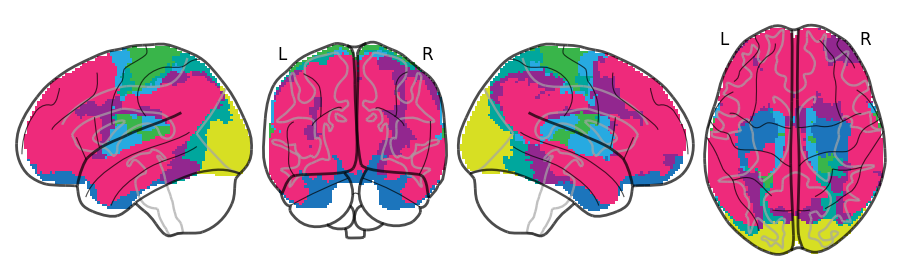

<Figure size 640x480 with 0 Axes>

In [13]:
my_cmap = ListedColormap(network_colors.values())
nii_fname = os.path.join('data/pieman/raw/Schaefer2018_1000Parcels_7Networks_order_FSLMNI152_2mm.nii.gz')
n_x = nlt.Brain_Data(nii_fname)
n_x.data = np.array([key.loc[i, 'code'] for i in n_x.data]).astype(float)
networks = n_x.to_nifti()
nl.plotting.plot_glass_brain(networks, cmap=network_cmap, display_mode='lyrz')
plt.show()
plt.clf()

In [14]:
# load network parcellations in CMU format
networks_cmu = nii2cmu(nii_fname)

# covert voxel values in the reference image to network codes
networks_cmu['Y'] = np.atleast_2d(np.array([key.loc[i, 'code'] for i in networks_cmu['Y']]).astype(float))
node_codes = node_labels(centers, widths, networks_cmu)
node_codes

,code,Network
0,4,Ventral attention
1,3,Dorsal attention
2,1,Visual
3,6,Frontoparietal
4,4,Ventral attention
...,...,...
695,2,Somatomotor
696,4,Ventral attention
697,4,Ventral attention
698,4,Ventral attention


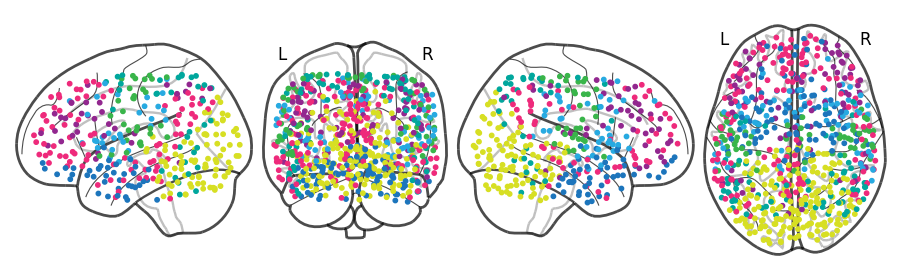

<Figure size 640x480 with 0 Axes>

In [15]:
nl.plotting.plot_connectome(np.eye(centers.shape[0]), centers, node_size=10, node_color=[colors[i] for i in node_codes['code']], display_mode='lyrz')
# add legend
plt.show()
plt.clf()

In [16]:
network_legend_list = list(network_colors.keys())
network_legend_list.reverse()
node_codes = node_labels(centers, widths, networks_cmu)
node_codes

,code,Network
0,4,Ventral attention
1,3,Dorsal attention
2,1,Visual
3,6,Frontoparietal
4,4,Ventral attention
...,...,...
695,2,Somatomotor
696,4,Ventral attention
697,4,Ventral attention
698,4,Ventral attention


In [17]:
network_legend_list

['Default mode',
 'Frontoparietal',
 'Limbic',
 'Ventral attention',
 'Dorsal attention',
 'Somatomotor',
 'Visual']

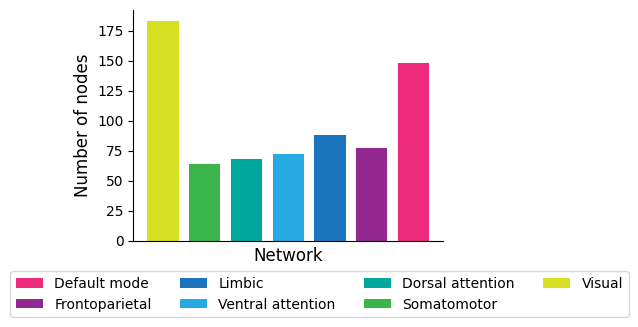

<Figure size 640x480 with 0 Axes>

In [18]:
fig = plt.figure(figsize=(4, 3))
ax = plt.gca()

sns.histplot(data=node_codes, x='code', color='k', shrink=0.75, hue='code', hue_order=range(1, 8), palette=colors[1:], alpha=1.0, legend=False, ax=ax, discrete=True, edgecolor=None)
ax.set_xlabel('Network', fontsize=12)
ax.set_ylabel('Number of nodes', fontsize=12)

ax.set_xticks([])
ax.spines[['right', 'top']].set_visible(False)
ax.legend(network_legend_list, loc='upper center', bbox_to_anchor=(0.6, -0.1),
          fancybox=True, ncol=4)
plt.show()
plt.clf()
fig.savefig(os.path.join('htfa_node_counts.pdf'), bbox_inches='tight')



# Across all conditions msaa

In [19]:
conds_all_list = intact_data_normalized + word_data_normalized + rest_data_normalized

condition_data = {
    'all': conds_all_list,
}


In [30]:
# ======================= MS-AA K sweep + purity scan + brain maps + ENHANCED decoding =======================

condition_labels = np.hstack((np.zeros(36), np.ones(36), np.ones(36)+1))

# ------------------ CONFIG ------------------
K_LIST             = [10, 25, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]          # dropped K=100 — saves significant time in both MS-AA and scan
MAXITER            = 200
RNG_SEED           = 12345

# Similarity scan / heatmaps
PURITY_THRESH      = 0.55
N_CLUSTERS         = 4
SIM_VMIN, SIM_VMAX = 0.0, 1.0

# Decoding hyperparameters
DECODE_NFOLDS      = 2
DECODE_NREPS       = 50
DECODE_SEED        = 2025
DEC_WINDOW_RADIUS  = 3  # time-embedding radius (0=off; try 2-4)
DEC_SMOOTH_T       = 1  # temporal moving-average radius (0=off; 1=>3-point)
DEC_ZTIME          = True  # z-score across time per node, within subject
DEC_ZFEAT          = True  # z-score across nodes per timepoint, within subject

# I/O
SAVE_DIR           = "msaa_scan_outputs"
PLOT_DIR           = os.path.join(SAVE_DIR, "plots")
SAVE_PLOTS         = True
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

# Condition names & shared colors (used for heatmaps and decoding plots)
COND_NAME_MAP = {0: "Intact", 1: "Word", 2: "Rest"}
COND_COLORS   = {0:"purple", 1:"green", 2:"black"}

# Brain plot threshold (keep nodes >= thr_frac * max weight)
SPATIAL_THR_FRAC = 0.30

# ------------------ Data expectations (provided by you) ------------------
#  - condition_data['all'] = [T x V arrays for all subjects]
#  - condition_labels      = array of length N with ints {0,1,2}
#  - Subject, coerce_TxV, multi_subject_aa available in scope
#  - centers (V x 3), node_codes['code'] length V, colors palette

# Verify labels match number of subjects
N_total = len(condition_data['all'])
assert len(condition_labels) == N_total, "condition_labels length must match number of subjects in condition_data['all']"
cond_codes  = np.asarray(condition_labels).astype(int)
cond_unique = np.unique(cond_codes)
idx_by_cond = {cc: np.where(cond_codes == cc)[0] for cc in cond_unique}

# ------------------ helpers: sanitize per-subject outputs ------------------
def _sanitize_subj_results(subj):
    sXC = np.array(subj["sXC"], dtype=float)
    S   = np.array(subj["S"],   dtype=float)
    sXC[~np.isfinite(sXC)] = 0.0
    S  [~np.isfinite(S)]   = 0.0
    subj["sXC"] = sXC
    subj["S"]   = S
    return subj

# ------------------ (A) Run MS-AA for each K and stack arrays ------------------
all_results_across_byK = {}     # K -> {'all': {...}}
arrays_byK = {}                 # K -> {'group_archs_array', 'group_coeffs_array'}

for K in K_LIST:
    subj_objs = [Subject(X=coerce_TxV(X), sX=coerce_TxV(X)) for X in condition_data['all']]
    opts = dict(maxiter=MAXITER, conv_crit=1e-6, fix_var_iter=5,
                heteroscedastic=False, use_gpu=True, rngSEED=RNG_SEED)
    results_subj, C, cost_fun, varexpl, secs = multi_subject_aa(subj_objs, noc=K, opts=opts)
    print(f"[K={K}] runtime {secs:.1f}s | VarExpl {100*varexpl:.2f}%  |  C: {C.shape}")

    results_subj = [_sanitize_subj_results(r) for r in results_subj]

    all_results_across_byK[K] = {
        'all': dict(results_subj=results_subj, C=C, cost_fun=cost_fun,
                    varexpl=varexpl, secs=secs, K=K, opts=opts)
    }

    # Stacks for scanning/decoding
    group_archs_array  = np.stack([r['sXC'] for r in results_subj], axis=0)  # (N, T, K)
    group_coeffs_array = np.stack([r['S']   for r in results_subj], axis=0)  # (N, K, V)
    arrays_byK[K] = dict(group_archs_array=group_archs_array,
                         group_coeffs_array=group_coeffs_array)


[K=10] runtime 60.5s | VarExpl 31.42%  |  C: (700, 10)
[K=25] runtime 359.0s | VarExpl 38.83%  |  C: (700, 25)
[K=50] runtime 478.7s | VarExpl 45.95%  |  C: (700, 50)
[K=55] runtime 199.5s | VarExpl 47.22%  |  C: (700, 55)
[K=60] runtime 370.7s | VarExpl 48.46%  |  C: (700, 60)
[K=65] runtime 327.6s | VarExpl 49.37%  |  C: (700, 65)
[K=70] runtime 311.3s | VarExpl 50.30%  |  C: (700, 70)
[K=75] runtime 164.1s | VarExpl 51.32%  |  C: (700, 75)
[K=80] runtime 291.4s | VarExpl 51.92%  |  C: (700, 80)
[K=85] runtime 263.6s | VarExpl 52.89%  |  C: (700, 85)
[K=90] runtime 224.8s | VarExpl 53.76%  |  C: (700, 90)
[K=95] runtime 410.7s | VarExpl 54.50%  |  C: (700, 95)
[K=100] runtime 228.8s | VarExpl 55.07%  |  C: (700, 100)


In [31]:
# ------------------ (B) Similarity & purity helpers (optimized) ------------------
from scipy.ndimage import uniform_filter1d

def purity(y_clust, y_class):
    y_clust = np.asarray(y_clust, dtype=int)
    y_class = np.asarray(y_class, dtype=int)
    Kc = int(np.max(y_clust))
    groups = [y_class[y_clust == k] for k in range(1, Kc+1)]
    correct = sum(np.bincount(g).max() if g.size else 0 for g in groups)
    return float(correct) / float(len(y_class))

def _subject_vectors_for_archetype(group_archs_array, group_coeffs_array, k, mode="A"):
    if mode.upper() == "A":
        return np.asarray(group_archs_array)[:, :, k]  # (N, T)
    else:
        return np.asarray(group_coeffs_array)[:, k, :]  # (N, V)

def _impute_and_zscore_rows(X, eps=1e-9):
    X = np.asarray(X, dtype=float)
    mask = ~np.isfinite(X)
    if mask.any():
        mu = np.nanmean(np.where(np.isfinite(X), X, np.nan), axis=1, keepdims=True)
        mu[~np.isfinite(mu)] = 0.0
        X = X.copy(); rr, cc = np.where(mask); X[rr, cc] = mu[rr, 0]
    m = X.mean(axis=1, keepdims=True)
    s = X.std(axis=1, keepdims=True)
    s[s < eps] = 1.0
    Z = (X - m) / s
    Z[~np.isfinite(Z)] = 0.0
    return Z

def _sim_pearson_safe(Xz):
    S = np.corrcoef(Xz)
    S = np.nan_to_num(S, nan=0.0, posinf=1.0, neginf=-1.0)
    S = np.clip(S, -1.0, 1.0)
    return (S + 1.0) * 0.5

def _sim_cosine_safe(X):
    X = np.asarray(X, dtype=float)
    n = np.linalg.norm(X, axis=1, keepdims=True)
    n[n == 0] = 1.0
    Y = X / n
    S = np.clip(Y @ Y.T, -1.0, 1.0)
    S = np.nan_to_num(S, nan=0.0, posinf=1.0, neginf=-1.0)
    return (S + 1.0) * 0.5

# OPTIMIZED: batch all K similarity matrices in one einsum instead of K separate corrcoef calls
def _batch_purity_scan(group_archs_array, condition_labels,
                       n_clusters=4, eps=1e-9):
    """
    Replaces the serial _compute_similarity_and_purity loop.
    Computes all K similarity matrices in a single batched matmul.
    group_archs_array: (N, T, K)
    Returns list of dicts with purity/order/sim_sorted/etc., one per archetype.
    """
    N, T, K = group_archs_array.shape
    X_all = group_archs_array.transpose(2, 0, 1).astype(float)  # (K, N, T)

    # Impute non-finite values
    bad = ~np.isfinite(X_all)
    if bad.any():
        row_means = np.nanmean(np.where(np.isfinite(X_all), X_all, np.nan), axis=2, keepdims=True)
        row_means = np.nan_to_num(row_means)
        X_all = np.where(bad, row_means, X_all)

    # Z-score each (k, subject) row
    mu = X_all.mean(axis=2, keepdims=True)
    sd = X_all.std(axis=2, keepdims=True)
    sd[sd < eps] = 1.0
    Xz = (X_all - mu) / sd                             # (K, N, T)

    # Batched Pearson: (K, N, T) x (K, T, N) -> (K, N, N)
    sim_batch = np.einsum('kni,kmi->knm', Xz, Xz) / T
    sim_batch = np.clip(sim_batch, -1.0, 1.0)
    sim_batch = np.nan_to_num(sim_batch, nan=0.5)
    np.einsum('kii->ki', sim_batch)[:] = 1.0            # set diagonals to 1
    sim_batch = (sim_batch + 1.0) * 0.5                 # map to [0,1]

    cond_arr = np.asarray(condition_labels, dtype=int)
    results  = []
    for k in range(K):
        sim  = sim_batch[k]
        dist = pairwise_distances(sim, metric='euclidean')
        Z    = linkage(dist, method='average')
        order   = leaves_list(Z)
        clabels = fcluster(Z, n_clusters, criterion='maxclust')
        cl_s    = clabels[order]
        co_s    = cond_arr[order]
        pur     = purity(cl_s, co_s)
        results.append(dict(
            k=k+1, purity=float(pur),
            order=order,
            sim_sorted=sim[np.ix_(order, order)],
            cl_sorted=cl_s,
            cond_sorted=co_s,
        ))
    return results

# Keep _compute_similarity_and_purity for single-archetype use (e.g. re-plotting a specific archetype)
def _compute_similarity_and_purity(
    group_archs_array, group_coeffs_array, condition_labels, k,
    mode="A", sim_metric="corr", dist_metric="euclidean",
    n_clusters=4, distance_threshold=None
):
    X = _subject_vectors_for_archetype(group_archs_array, group_coeffs_array, k, mode=mode)
    Xz = _impute_and_zscore_rows(X)
    sim = _sim_pearson_safe(Xz) if sim_metric.lower()=="corr" else _sim_cosine_safe(X)
    sim = np.nan_to_num(sim, nan=0.5, posinf=1.0, neginf=0.0)
    np.fill_diagonal(sim, 1.0)
    dist = pairwise_distances(sim, metric=dist_metric)
    Z = linkage(dist, method="average")
    order = leaves_list(Z)
    clabels = (fcluster(Z, t=distance_threshold, criterion='distance')
               if distance_threshold is not None
               else fcluster(Z, n_clusters, criterion='maxclust'))
    cl_sorted   = clabels[order]
    cond_sorted = np.asarray(condition_labels)[order]
    pur = purity(cl_sorted, cond_sorted)
    return dict(
        purity=float(pur),
        order=order.astype(int),
        sim_sorted=sim[np.ix_(order, order)],
        cl_sorted=cl_sorted.astype(int),
        cond_sorted=cond_sorted.astype(int),
    )

def plot_archetype_similarity_heatmap_nan_robust_labeled(
    group_archs_array, group_coeffs_array, condition_labels, k,
    mode="A", sim_metric="corr", dist_metric="euclidean",
    n_clusters=4, distance_threshold=None,
    tick_colors_map=None, subj_labels=None, tick_every=2, label_size=8,
    vmin=0.0, vmax=1.0, title_prefix="Archetype", plot_save=None,
    precomputed_comp=None   # pass result from _batch_purity_scan to skip recompute
):
    comp = precomputed_comp if precomputed_comp is not None else _compute_similarity_and_purity(
        group_archs_array, group_coeffs_array, condition_labels, k,
        mode=mode, sim_metric=sim_metric, dist_metric=dist_metric,
        n_clusters=n_clusters, distance_threshold=distance_threshold
    )
    sim_sorted  = comp["sim_sorted"]
    cl_sorted   = comp["cl_sorted"]
    cond_sorted = comp["cond_sorted"]
    purity_val  = comp["purity"]
    order       = comp["order"]
    N           = sim_sorted.shape[0]

    if tick_colors_map is None:
        uniq = np.unique(condition_labels)
        pal  = sns.color_palette("Set2", len(uniq))
        tick_colors_map = {int(u): pal[i] for i,u in enumerate(uniq)}
    tick_colors = [tick_colors_map[int(c)] for c in cond_sorted]

    if subj_labels is None:
        subj_labels = [f"S{i+1}" for i in range(N)]
    subj_sorted = [subj_labels[i] for i in order]

    show_mask = np.zeros(N, dtype=bool); show_mask[::max(1,int(tick_every))] = True
    x_labels = [lab if m else "" for lab, m in zip(subj_sorted, show_mask)]
    y_labels = x_labels

    b_cl = np.where(np.diff(cl_sorted)   != 0)[0] + 1
    b_y  = np.where(np.diff(cond_sorted) != 0)[0] + 1

    plt.figure(figsize=(10, 8))
    ax = sns.heatmap(sim_sorted, cmap="coolwarm", vmin=vmin, vmax=vmax,
                     xticklabels=x_labels, yticklabels=y_labels,
                     square=True, cbar_kws={'label':'Similarity'})
    for tl, col in zip(ax.get_xticklabels(), tick_colors):
        tl.set_color(col); tl.set_rotation(90); tl.set_fontsize(label_size)
    for tl, col in zip(ax.get_yticklabels(), tick_colors):
        tl.set_color(col); tl.set_fontsize(label_size)
    for b in b_cl: ax.axhline(b, color='black', linewidth=2); ax.axvline(b, color='black', linewidth=2)
    for b in b_y:  ax.axhline(b, color='gray', linewidth=1, alpha=0.6); ax.axvline(b, color='gray', linewidth=1, alpha=0.6)
    plt.title(f"{title_prefix} {k+1} | Purity: {purity_val:.2f}")
    plt.xlabel("Subjects (clustered)"); plt.ylabel("Subjects (clustered)")
    plt.tight_layout()
    if plot_save:
        plt.savefig(plot_save, dpi=150, bbox_inches="tight")
        plt.close()
    else:
        plt.show(); plt.close()
    return comp

def scan_archetypes_nan_robust(
    group_archs_array, group_coeffs_array, condition_labels,
    mode="A", sim_metric="corr", dist_metric="euclidean",
    n_clusters=4, distance_threshold=None,
    tick_colors_map=None, vmin=0.0, vmax=1.0,
    purity_thresh=None, show_plots=True, save_dir=None,
    title_prefix="Archetype", subj_labels=None, tick_every=2, label_size=8, verbose=True
):
    """
    OPTIMIZED: uses _batch_purity_scan to compute all K similarity matrices
    in one batched matmul, then only loops for plotting.
    """
    K = group_archs_array.shape[2]
    if save_dir: os.makedirs(save_dir, exist_ok=True)

    # Batch compute all purity scores at once (the expensive part)
    all_comps = _batch_purity_scan(
        group_archs_array, condition_labels,
        n_clusters=n_clusters
    )

    rows = []
    for comp in all_comps:
        k    = comp['k'] - 1   # 0-based for plotting function
        p    = comp['purity']
        will_plot = (purity_thresh is None) or (p >= float(purity_thresh))
        if verbose: print(f"[k={k+1:03d}] purity={p:.3f}  -> {'PLOT' if will_plot else 'skip'}")

        if will_plot and (show_plots or save_dir):
            out_png = os.path.join(save_dir, f"{title_prefix.replace(' ','_')}_k{str(k+1).zfill(3)}_pur_{p:.2f}.png") if save_dir else None
            plot_archetype_similarity_heatmap_nan_robust_labeled(
                group_archs_array, group_coeffs_array, condition_labels, k,
                mode=mode, sim_metric=sim_metric, dist_metric=dist_metric,
                n_clusters=n_clusters, distance_threshold=distance_threshold,
                tick_colors_map=tick_colors_map, subj_labels=subj_labels,
                tick_every=tick_every, label_size=label_size,
                vmin=vmin, vmax=vmax, title_prefix=title_prefix, plot_save=out_png,
                precomputed_comp=comp   # reuse, no double-compute
            )
        rows.append({"k": comp['k'], "purity": p, "plotted": bool(will_plot)})

    return pd.DataFrame(rows).sort_values("purity", ascending=False).reset_index(drop=True)

# ------------------ (C) Brain plots + network hist + coords for winners ------------------
def plot_group_mean_spatial_maps_with_hist(
    all_results_for_one_cond,
    centers,
    node_codes,
    colors,
    k_list,
    thr_frac=0.30,
    display_mode='lyrz',
    title_prefix="Group avg",
    save_dir=None,
    file_prefix=None,
    file_ext="png",
    dpi=150,
    make_hist=True,
    network_legend=None
):
    S_stack = np.stack([subj["S"] for subj in all_results_for_one_cond["results_subj"]], axis=0)  # (N, K, V)
    S_group_mean = S_stack.mean(axis=0)  # (K, V)
    K_here = S_group_mean.shape[0]
    if "K" in all_results_for_one_cond:
        K_for_name = int(all_results_for_one_cond["K"])
    else:
        K_for_name = K_here
    if save_dir: os.makedirs(save_dir, exist_ok=True)
    if file_prefix is None: file_prefix = f"K{K_for_name}_groupavg"
    codes_array = np.asarray(node_codes["code"])
    for k_in in k_list:
        k0 = int(k_in) - 1
        if k0 < 0 or k0 >= K_here:
            print(f"[warn] A{k_in} out of range 1..{K_here}; skipping.")
            continue
        w = S_group_mean[k0]
        if not np.isfinite(w).any() or float(np.nanmax(w)) <= 0:
            print(f"[warn] A{k_in}: non-positive/NaN max; skipping.")
            continue
        thr = float(w.max()) * float(thr_frac)
        keep = w >= thr
        centers_sel = centers[keep]
        codes_sel   = codes_array[keep]
        node_colors = [colors[int(c)] for c in codes_sel]
        display = nl.plotting.plot_connectome(
            adjacency_matrix=np.eye(len(centers_sel)),
            node_coords=centers_sel,
            node_color=node_colors,
            node_size=10,
            display_mode=display_mode,
            title=f"{title_prefix} | A{k_in}"
        )
        if save_dir:
            brain_path = os.path.join(save_dir, f"{file_prefix}_A{int(k_in):03d}.{file_ext}")
            try:
                display.savefig(brain_path, dpi=dpi)
                print(f"Saved brain plot: {brain_path}")
            except Exception as e:
                plt.savefig(brain_path, dpi=dpi, bbox_inches="tight")
                print(f"Saved brain plot (fallback): {brain_path}  ({e})")
        try:
            display.close()
        except Exception:
            pass
        plt.close('all')
        if make_hist and save_dir:
            fig = plt.figure(figsize=(4,3)); ax = plt.gca()
            df_hist = pd.DataFrame({"code": codes_sel})
            sns.histplot(
                data=df_hist, x='code', color='k', shrink=0.75,
                hue='code', hue_order=range(1,8),
                palette=colors[1:], alpha=1.0, legend=False,
                ax=ax, discrete=True, edgecolor=None
            )
            ax.set_xlabel('Network', fontsize=12)
            ax.set_ylabel('Number of nodes', fontsize=12)
            ax.set_xticks([])
            ax.spines[['right','top']].set_visible(False)
            if network_legend:
                ax.legend(network_legend, loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False)
            plt.tight_layout()
            hist_path = os.path.join(save_dir, f"{file_prefix}_A{int(k_in):03d}_hist.{file_ext}")
            plt.savefig(hist_path, dpi=dpi, bbox_inches='tight')
            plt.close()

def collect_coords_for_winners(all_results_for_one_cond, centers, node_codes, k_list, K, thr_frac=0.30):
    S_stack = np.stack([subj["S"] for subj in all_results_for_one_cond["results_subj"]], axis=0)
    S_group_mean = S_stack.mean(axis=0)
    codes_array = np.asarray(node_codes["code"])
    rows = []
    for k_in in k_list:
        k0 = int(k_in) - 1
        w = S_group_mean[k0]
        if not np.isfinite(w).any() or w.max() <= 0: continue
        keep = w >= (thr_frac * w.max())
        for (x,y,z), code, weight in zip(centers[keep], codes_array[keep], w[keep]):
            rows.append({"K": K, "archetype": int(k_in), "x": float(x), "y": float(y), "z": float(z),
                         "code": int(code), "weight": float(weight)})
    return pd.DataFrame(rows)

# ------------------ (D) Reconstruction & OPTIMIZED decoding ------------------
def reconstruct_from_A_S(A, S, use_k=None, ztime=False, zfeat=False):
    """
    A: (N,T,K), S: (N,K,V)
    If use_k is None, sum over all K. Else use_k is a list of 0-based indices.
    """
    N, T, K = A.shape
    V = S.shape[2]
    X = np.zeros((N, T, V), dtype=np.float32)
    if use_k is None:
        for i in range(N):
            X[i] = A[i] @ S[i]         # (T,K) @ (K,V)
    else:
        idxs = np.asarray(use_k, dtype=int)
        for i in range(N):
            for k in idxs:
                X[i] += np.outer(A[i, :, k], S[i, k, :])
    if ztime:
        mu = X.mean(axis=1, keepdims=True)
        sd = X.std(axis=1, keepdims=True) + 1e-12
        X = (X - mu) / sd
    if zfeat:
        mu2 = X.mean(axis=2, keepdims=True)
        sd2 = X.std(axis=2, keepdims=True) + 1e-12
        X = (X - mu2) / sd2
    X[~np.isfinite(X)] = 0.0
    return X

# OPTIMIZED: vectorized moving average (replaces apply_along_axis + convolve)
def _moving_average_along_time(X_TV, radius: int):
    if radius is None or radius <= 0:
        return X_TV
    return uniform_filter1d(X_TV, size=2*radius+1, axis=0, mode='nearest')

# OPTIMIZED: strided time-embedding (replaces Python loop over T)
def time_embed_matrix(X_TV, radius: int):
    if radius is None or radius <= 0:
        return X_TV
    T, V = X_TV.shape
    W = 2 * radius + 1
    # Pad edges so boundary timepoints repeat (matches original clamp logic)
    X_pad = np.pad(X_TV, ((radius, radius), (0, 0)), mode='edge')
    # Stride trick: view as (T, W, V) without copying, then reshape to (T, W*V)
    shape   = (T, W, V)
    strides = (X_pad.strides[0], X_pad.strides[0], X_pad.strides[1])
    embedded = np.lib.stride_tricks.as_strided(X_pad, shape=shape, strides=strides)
    return embedded.reshape(T, W * V).copy()   # .copy() to own the memory

def prep_stack_for_decoding(X_stack, ztime=True, zfeat=True, eps=1e-8):
    Y = np.array(X_stack, dtype=float, copy=True)  # (N,T,V)
    if ztime:
        mu = Y.mean(axis=1, keepdims=True)
        sd = Y.std(axis=1, keepdims=True) + eps
        Y = (Y - mu) / sd
    if zfeat:
        mu2 = Y.mean(axis=2, keepdims=True)
        sd2 = Y.std(axis=2, keepdims=True) + eps
        Y = (Y - mu2) / sd2
    Y[~np.isfinite(Y)] = 0.0
    return Y

def get_xval_assignments(N, nfolds, rng):
    groups = np.zeros(N, dtype=int); gsz = int(np.ceil(N / nfolds))
    for i in range(1, nfolds):
        inds = np.arange(i * gsz, min((i + 1) * gsz, N))
        groups[inds] = i
    rng.shuffle(groups); return groups

def _decode_metrics_from_corr(corrs):
    T = corrs.shape[0]; acc = err = rnk = 0.0
    for t in range(T):
        pred = int(np.argmax(corrs[t]))
        acc += (pred == t)
        err += np.mean(np.abs(pred - t)) / T
        rnk += np.mean((corrs[t] <= corrs[t, t]).astype(int))
    return dict(accuracy=acc/T, error=err/T, rank=rnk/T)

# OPTIMIZED: replaces per-subject cdist loop with a single batched matmul
def run_timepoint_decoding_enhanced(X_stack, nfolds=2, nreps=5, seed=2025,
                                     window_radius=3, smooth_radius=1):
    """
    Key changes vs original:
      - time_embed_matrix: strided numpy instead of Python loop over T
      - _moving_average_along_time: scipy uniform_filter1d instead of apply_along_axis
      - correlation matrix: single batched einsum over all out-fold subjects
        instead of per-subject cdist calls
    Results are numerically identical.
    """
    N, T, V = X_stack.shape
    rng  = np.random.default_rng(seed)
    rows = []

    for rep in range(nreps):
        fold_ids = get_xval_assignments(N, nfolds, rng)

        for fold in range(nfolds):
            in_mask  = (fold_ids == fold)
            out_mask = ~in_mask

            # Template: mean of in-fold subjects
            X_in_mean = X_stack[in_mask].mean(axis=0)           # (T, V)
            if smooth_radius and smooth_radius > 0:
                X_in_mean = _moving_average_along_time(X_in_mean, smooth_radius)
            T_in = time_embed_matrix(X_in_mean, window_radius)  # (T, FV)

            # Z-score template rows for correlation via matmul
            T_in_z = T_in - T_in.mean(axis=1, keepdims=True)
            T_in_n = np.linalg.norm(T_in_z, axis=1, keepdims=True)
            T_in_n[T_in_n == 0] = 1.0
            T_in_z /= T_in_n                                    # (T, FV) unit rows

            # Smooth + embed all out-fold subjects
            X_out = X_stack[out_mask]                           # (Nout, T, V)
            nout  = X_out.shape[0]
            if smooth_radius and smooth_radius > 0:
                X_out = np.stack([_moving_average_along_time(x, smooth_radius) for x in X_out])
            T_out_all = np.stack([time_embed_matrix(x, window_radius) for x in X_out])  # (Nout, T, FV)

            # Z-score each subject's rows
            mu      = T_out_all.mean(axis=2, keepdims=True)
            T_out_z = T_out_all - mu
            nrm     = np.linalg.norm(T_out_z, axis=2, keepdims=True)
            nrm[nrm == 0] = 1.0
            T_out_z /= nrm                                      # (Nout, T, FV)

            # Single batched matmul: mean correlation matrix over all out-fold subjects
            # (Nout*T, FV) @ (FV, T) -> (Nout*T, T) -> (Nout, T, T) -> mean -> (T, T)
            corrs = (T_out_z.reshape(nout * T, -1) @ T_in_z.T
                     ).reshape(nout, T, T).mean(axis=0)

            mets = _decode_metrics_from_corr(corrs)
            rows.append(dict(rep=rep, fold=fold, **mets))

    return pd.DataFrame(rows)

# ------------------ (E) MAIN: scan winners, brain maps, decoding ------------------
dec_rows      = []
dec_full_rows = []
coords_records = []
winners_byK   = {}

for K in K_LIST:
    print(f"\n=== K={K} ===")
    arrays = arrays_byK[K]
    ga = arrays['group_archs_array']   # (N, T, K)
    gs = arrays['group_coeffs_array']  # (N, K, V)
    N = ga.shape[0]

    k_dir = os.path.join(SAVE_DIR, f"K_{K}")
    if SAVE_PLOTS: os.makedirs(k_dir, exist_ok=True)

    # Scan winners by purity (batched)
    summary = scan_archetypes_nan_robust(
        ga, gs, condition_labels, mode="A", sim_metric="corr", dist_metric="euclidean",
        n_clusters=N_CLUSTERS, distance_threshold=None,
        tick_colors_map=COND_COLORS, vmin=SIM_VMIN, vmax=SIM_VMAX,
        purity_thresh=PURITY_THRESH, show_plots=True,
        save_dir=(os.path.join(k_dir, "heatmaps") if SAVE_PLOTS else None),
        title_prefix="A-timecourse", subj_labels=[f"subj{i+1}" for i in range(N)],
        tick_every=2, label_size=8, verbose=True
    )
    winners = summary.query("plotted == True")["k"].astype(int).tolist()
    winners_byK[K] = winners
    print(f"[K={K}] winners (pur>={PURITY_THRESH}):", winners)

    # Brain plots + coords for winners
    if len(winners) and SAVE_PLOTS and 'all' in all_results_across_byK[K]:
        brain_dir = os.path.join(k_dir, "brain_maps")
        os.makedirs(brain_dir, exist_ok=True)
        plot_group_mean_spatial_maps_with_hist(
            all_results_for_one_cond=all_results_across_byK[K]['all'],
            centers=centers, node_codes=node_codes, colors=colors,
            k_list=winners, thr_frac=SPATIAL_THR_FRAC,
            display_mode='lyrz', title_prefix=f"Group avg | K={K}",
            save_dir=brain_dir, file_prefix=f"K{K}_groupavg", file_ext="png", dpi=150,
            make_hist=True, network_legend=None
        )
        coords_df = collect_coords_for_winners(
            all_results_across_byK[K]['all'],
            centers=centers, node_codes=node_codes,
            k_list=winners, K=K, thr_frac=SPATIAL_THR_FRAC
        )
        if len(coords_df):
            coords_records.append(coords_df)
            coords_df.to_csv(os.path.join(k_dir, f"K{K}_winners_coords.csv"), index=False)

    # Reconstructions
    A = ga  # (N,T,K)
    S = gs  # (N,K,V)

    X_all      = reconstruct_from_A_S(A, S, use_k=None, ztime=False, zfeat=False)
    X_best     = None
    X_per_arch = {}
    if len(winners):
        idx_keep = [w-1 for w in winners]
        X_best = reconstruct_from_A_S(A, S, use_k=idx_keep, ztime=False, zfeat=False)
        for k1 in winners:
            X_per_arch[k1] = reconstruct_from_A_S(A, S, use_k=[k1-1], ztime=False, zfeat=False)

    def _decode_and_record(X, tag_set, cname):
        Xn = prep_stack_for_decoding(X, ztime=DEC_ZTIME, zfeat=DEC_ZFEAT)
        df = run_timepoint_decoding_enhanced(
            Xn,
            nfolds=DECODE_NFOLDS,
            nreps=DECODE_NREPS,
            seed=DECODE_SEED,
            window_radius=DEC_WINDOW_RADIUS,
            smooth_radius=DEC_SMOOTH_T
        )
        dff = df.copy()
        dff["K"] = K; dff["set"] = tag_set; dff["condition"] = cname
        dec_full_rows.append(dff)
        dec_rows.append({"K": K, "set": tag_set, "condition": cname, "accuracy": float(df["accuracy"].mean())})

    _decode_and_record(X_all, "all_archetypes", "ALL")
    for c in cond_unique:
        idx = idx_by_cond[c]
        if len(idx) >= 2:
            _decode_and_record(X_all[idx], "all_archetypes", COND_NAME_MAP.get(int(c), str(int(c))))

    if X_best is not None:
        _decode_and_record(X_best, "combined_best", "ALL")
        for c in cond_unique:
            idx = idx_by_cond[c]
            if len(idx) >= 2:
                _decode_and_record(X_best[idx], "combined_best", COND_NAME_MAP.get(int(c), str(int(c))))
        for k1 in winners:
            _decode_and_record(X_per_arch[k1], f"A{str(k1).zfill(3)}", "ALL")
            for c in cond_unique:
                idx = idx_by_cond[c]
                if len(idx) >= 2:
                    _decode_and_record(X_per_arch[k1][idx], f"A{str(k1).zfill(3)}", COND_NAME_MAP.get(int(c), str(int(c))))

# Final decoding DataFrames
decoding_df      = pd.DataFrame(dec_rows)
decoding_df_full = (pd.concat(dec_full_rows, ignore_index=True)
                    if len(dec_full_rows) else pd.DataFrame(columns=["K","set","condition","rep","fold","accuracy","error","rank"]))

if SAVE_PLOTS:
    decoding_df.to_csv(os.path.join(SAVE_DIR, "decoding_summary_means.csv"), index=False)
    decoding_df_full.to_csv(os.path.join(SAVE_DIR, "decoding_summary_full.csv"), index=False)

if coords_records:
    coords_all = pd.concat(coords_records, ignore_index=True)
    if SAVE_PLOTS:
        coords_all.to_csv(os.path.join(SAVE_DIR, "all_winner_coords.csv"), index=False)
    print(f"Saved {len(coords_all)} winner-node coordinates to CSV.")

print("\nWinners by K (1-based):", {k: v for k, v in winners_byK.items()})

# ------------------ (F) K-vs-accuracy plots ------------------
def _apply_ylim(ax, y_min, y_max):
    if y_min is not None or y_max is not None:
        lo, hi = ax.get_ylim()
        ax.set_ylim(y_min if y_min is not None else lo,
                    y_max if y_max is not None else hi)

def _cond_palette_from_map(cond_names):
    base = COND_COLORS.copy()
    pal = {}
    for c in cond_names:
        inv = {v:k for k,v in COND_NAME_MAP.items()}
        code = inv.get(c, None)
        pal[c] = base.get(code, plt.cm.Set2(0))
    return pal

def plot_k_vs_accuracy_all_by_condition(dec_df_full, K_list, y_min=None, y_max=None, save_path=None):
    df = dec_df_full.copy()
    df = df[df['set'] == 'all_archetypes']
    conds = [c for c in sorted(df['condition'].unique()) if c != 'ALL']
    pal   = _cond_palette_from_map(conds)
    def mean_se(sub):
        g = sub.groupby('K')["accuracy"]
        mu = g.mean(); se = g.std().div(np.sqrt(g.count()).clip(lower=1))
        return mu, se
    plt.figure(figsize=(9,6))
    for cname in conds:
        sub = df[df['condition'] == cname]
        if len(sub):
            mu, se = mean_se(sub)
            plt.errorbar(mu.index, mu.values, yerr=se.values, fmt='-o', capsize=4,
                         color=pal[cname], label=f"All ({cname})")
    plt.xlabel("Number of archetypes (K)"); plt.ylabel("Decoding accuracy")
    plt.title("Timepoint decoding vs K - All archetypes (by condition)")
    plt.grid(alpha=0.3, linestyle='--')
    _apply_ylim(plt.gca(), y_min, y_max)
    plt.xticks(sorted(K_list))
    plt.legend(ncol=2, frameon=False)
    plt.tight_layout()
    if save_path and SAVE_PLOTS: plt.savefig(save_path, dpi=150)
    plt.show(); plt.close()

def _winner_masked_df(dec_df_full, winners_byK):
    d = dec_df_full.copy()
    maskA = d['set'].astype(str).str.match(r'^A\d+$', na=False)
    d = d[maskA].copy()
    if d.empty: return d
    d['arch_id'] = d['set'].str.extract(r'^A0*([0-9]+)$').astype(int)
    keep_mask = d.apply(lambda r: r['arch_id'] in winners_byK.get(int(r['K']), []), axis=1)
    return d[keep_mask].copy()

def plot_k_vs_accuracy_winners_by_condition(dec_df_full, winners_byK, K_list, y_min=None, y_max=None, save_path=None):
    dfW = _winner_masked_df(dec_df_full, winners_byK)
    if dfW.empty:
        print("No per-winner rows found. Did you decode individual winners?"); return
    conds = [c for c in sorted(dfW['condition'].unique()) if c != 'ALL']
    pal   = _cond_palette_from_map(conds)
    plt.figure(figsize=(9,6))
    rng = np.random.default_rng(0)
    for cname in conds:
        sub = dfW[dfW['condition'] == cname]
        if not len(sub): continue
        arch_means = (sub.groupby(['K','set'])['accuracy'].mean().reset_index())
        g = arch_means.groupby('K')['accuracy']
        mu = g.mean(); se = g.std().div(np.sqrt(g.count()).clip(lower=1))
        plt.errorbar(mu.index, mu.values, yerr=se.values, fmt='o-', capsize=4,
                     color=pal[cname], label=f"Winners mean+-SE ({cname})")
        jitter = rng.normal(0, 0.08, size=len(arch_means))
        plt.scatter(arch_means['K'] + jitter, arch_means['accuracy'],
                    s=20, alpha=0.25, color=pal[cname])
    plt.xlabel("Number of archetypes (K)"); plt.ylabel("Decoding accuracy")
    plt.title("Timepoint decoding vs K - Per winning archetype (by condition)")
    plt.grid(alpha=0.3, linestyle='--')
    _apply_ylim(plt.gca(), y_min, y_max)
    plt.xticks(sorted(K_list))
    plt.legend(ncol=2, frameon=False)
    plt.tight_layout()
    if save_path and SAVE_PLOTS: plt.savefig(save_path, dpi=150)
    plt.show(); plt.close()

def plot_k_vs_accuracy_combined_winners_by_condition(dec_df_full, K_list, y_min=None, y_max=None, save_path=None):
    df = dec_df_full.copy()
    df = df[df['set'] == 'combined_best']
    if df.empty:
        print("No combined_best rows found (no winners for some K?)."); return
    conds = [c for c in sorted(df['condition'].unique()) if c != 'ALL']
    pal   = _cond_palette_from_map(conds)
    def mean_se(sub):
        g = sub.groupby('K')["accuracy"]
        mu = g.mean(); se = g.std().div(np.sqrt(g.count()).clip(lower=1))
        return mu, se
    plt.figure(figsize=(9,6))
    for cname in conds:
        sub = df[df['condition'] == cname]
        if len(sub):
            mu, se = mean_se(sub)
            plt.errorbar(mu.index, mu.values, yerr=se.values, fmt='--o', capsize=4,
                         color=pal[cname], label=f"Combined winners ({cname})")
    plt.xlabel("Number of archetypes (K)"); plt.ylabel("Decoding accuracy")
    plt.title("Timepoint decoding vs K - Combined winning archetypes (by condition)")
    plt.grid(alpha=0.3, linestyle='--')
    _apply_ylim(plt.gca(), y_min, y_max)
    plt.xticks(sorted(K_list))
    plt.legend(ncol=2, frameon=False)
    plt.tight_layout()
    if save_path and SAVE_PLOTS: plt.savefig(save_path, dpi=150)
    plt.show(); plt.close()



=== K=10 ===
[k=001] purity=0.759  -> PLOT


/tmp/ipykernel_30265/3637464364.py:84: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z    = linkage(dist, method='average')
/tmp/ipykernel_30265/3637464364.py:84: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z    = linkage(dist, method='average')
/tmp/ipykernel_30265/3637464364.py:84: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z    = linkage(dist, method='average')
/tmp/ipykernel_30265/3637464364.py:84: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z    = linkage(dist, method='average')
/tmp/ipykernel_30265/3637464364.py:84: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z    = linkage(dist

[k=002] purity=0.556  -> PLOT
[k=003] purity=0.611  -> PLOT
[k=004] purity=0.398  -> skip
[k=005] purity=0.657  -> PLOT
[k=006] purity=0.417  -> skip
[k=007] purity=0.417  -> skip
[k=008] purity=0.370  -> skip
[k=009] purity=0.546  -> skip
[k=010] purity=0.407  -> skip
[K=10] winners (pur>=0.55): [1, 5, 3, 2]
Saved brain plot: msaa_scan_outputs/K_10/brain_maps/K10_groupavg_A001.png
Saved brain plot: msaa_scan_outputs/K_10/brain_maps/K10_groupavg_A005.png
Saved brain plot: msaa_scan_outputs/K_10/brain_maps/K10_groupavg_A003.png
Saved brain plot: msaa_scan_outputs/K_10/brain_maps/K10_groupavg_A002.png

=== K=25 ===
[k=001] purity=0.370  -> skip
[k=002] purity=0.806  -> PLOT


/tmp/ipykernel_30265/3637464364.py:84: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z    = linkage(dist, method='average')
/tmp/ipykernel_30265/3637464364.py:84: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z    = linkage(dist, method='average')
/tmp/ipykernel_30265/3637464364.py:84: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z    = linkage(dist, method='average')
/tmp/ipykernel_30265/3637464364.py:84: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z    = linkage(dist, method='average')
/tmp/ipykernel_30265/3637464364.py:84: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z    = linkage(dist

[k=003] purity=0.722  -> PLOT
[k=004] purity=0.602  -> PLOT
[k=005] purity=0.500  -> skip
[k=006] purity=0.630  -> PLOT
[k=007] purity=0.454  -> skip
[k=008] purity=0.463  -> skip
[k=009] purity=0.435  -> skip
[k=010] purity=0.546  -> skip
[k=011] purity=0.389  -> skip
[k=012] purity=0.417  -> skip
[k=013] purity=0.407  -> skip
[k=014] purity=0.407  -> skip
[k=015] purity=0.389  -> skip
[k=016] purity=0.398  -> skip
[k=017] purity=0.435  -> skip
[k=018] purity=0.361  -> skip
[k=019] purity=0.361  -> skip
[k=020] purity=0.389  -> skip
[k=021] purity=0.361  -> skip
[k=022] purity=0.380  -> skip
[k=023] purity=0.361  -> skip
[k=024] purity=0.389  -> skip
[k=025] purity=0.352  -> skip
[K=25] winners (pur>=0.55): [2, 3, 6, 4]
Saved brain plot: msaa_scan_outputs/K_25/brain_maps/K25_groupavg_A002.png
Saved brain plot: msaa_scan_outputs/K_25/brain_maps/K25_groupavg_A003.png
Saved brain plot: msaa_scan_outputs/K_25/brain_maps/K25_groupavg_A006.png
Saved brain plot: msaa_scan_outputs/K_25/brain_

...

[k=001] purity=0.380  -> skip
[k=002] purity=0.509  -> skip
[k=003] purity=0.361  -> skip
[k=004] purity=0.370  -> skip
[k=005] purity=0.444  -> skip
[k=006] purity=0.370  -> skip
[k=007] purity=0.417  -> skip
[k=008] purity=0.852  -> PLOT
[k=009] purity=0.880  -> PLOT
[k=010] purity=0.583  -> PLOT
[k=011] purity=0.435  -> skip
[k=012] purity=0.667  -> PLOT
[k=013] purity=0.528  -> skip
[k=014] purity=0.537  -> skip
[k=015] purity=0.657  -> PLOT
[k=016] purity=0.463  -> skip
[k=017] purity=0.407  -> skip
[k=018] purity=0.398  -> skip
[k=019] purity=0.546  -> skip
[k=020] purity=0.407  -> skip
[k=021] purity=0.380  -> skip
[k=022] purity=0.398  -> skip
[k=023] purity=0.389  -> skip
[k=024] purity=0.407  -> skip
[k=025] purity=0.380  -> skip
[k=026] purity=0.380  -> skip
[k=027] purity=0.565  -> PLOT
[k=028] purity=0.398  -> skip
[k=029] purity=0.407  -> skip
[k=030] purity=0.417  -> skip
[k=031] purity=0.389  -> skip
[k=032] purity=0.417  -> skip
[k=033] purity=0.361  -> skip
[k=034] pu

/tmp/ipykernel_30265/3637464364.py:84: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z    = linkage(dist, method='average')
/tmp/ipykernel_30265/3637464364.py:84: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z    = linkage(dist, method='average')
/tmp/ipykernel_30265/3637464364.py:84: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z    = linkage(dist, method='average')
/tmp/ipykernel_30265/3637464364.py:84: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z    = linkage(dist, method='average')
/tmp/ipykernel_30265/3637464364.py:84: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z    = linkage(dist

[k=001] purity=0.380  -> skip
[k=002] purity=0.509  -> skip
[k=003] purity=0.444  -> skip
[k=004] purity=0.417  -> skip
[k=005] purity=0.370  -> skip
[k=006] purity=0.370  -> skip
[k=007] purity=0.546  -> skip
[k=008] purity=0.361  -> skip
[k=009] purity=0.889  -> PLOT
[k=010] purity=0.583  -> PLOT
[k=011] purity=0.556  -> PLOT
[k=012] purity=0.667  -> PLOT
[k=013] purity=0.361  -> skip
[k=014] purity=0.500  -> skip
[k=015] purity=0.565  -> PLOT
[k=016] purity=0.537  -> skip
[k=017] purity=0.491  -> skip
[k=018] purity=0.426  -> skip
[k=019] purity=0.426  -> skip
[k=020] purity=0.398  -> skip
[k=021] purity=0.519  -> skip
[k=022] purity=0.407  -> skip
[k=023] purity=0.380  -> skip
[k=024] purity=0.398  -> skip
[k=025] purity=0.426  -> skip
[k=026] purity=0.389  -> skip
[k=027] purity=0.407  -> skip
[k=028] purity=0.370  -> skip
[k=029] purity=0.380  -> skip
[k=030] purity=0.565  -> PLOT
[k=031] purity=0.398  -> skip
[k=032] purity=0.407  -> skip
[k=033] purity=0.417  -> skip
[k=034] pu

/tmp/ipykernel_30265/3637464364.py:84: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z    = linkage(dist, method='average')
/tmp/ipykernel_30265/3637464364.py:84: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z    = linkage(dist, method='average')
/tmp/ipykernel_30265/3637464364.py:84: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z    = linkage(dist, method='average')
/tmp/ipykernel_30265/3637464364.py:84: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z    = linkage(dist, method='average')
/tmp/ipykernel_30265/3637464364.py:84: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z    = linkage(dist

[k=001] purity=0.417  -> skip
[k=002] purity=0.444  -> skip
[k=003] purity=0.361  -> skip
[k=004] purity=0.370  -> skip
[k=005] purity=0.370  -> skip
[k=006] purity=0.509  -> skip
[k=007] purity=0.380  -> skip
[k=008] purity=0.889  -> PLOT
[k=009] purity=0.593  -> PLOT
[k=010] purity=0.657  -> PLOT
[k=011] purity=0.546  -> skip
[k=012] purity=0.361  -> skip
[k=013] purity=0.602  -> PLOT
[k=014] purity=0.537  -> skip
[k=015] purity=0.426  -> skip
[k=016] purity=0.509  -> skip
[k=017] purity=0.370  -> skip
[k=018] purity=0.546  -> skip
[k=019] purity=0.398  -> skip
[k=020] purity=0.519  -> skip
[k=021] purity=0.407  -> skip
[k=022] purity=0.380  -> skip
[k=023] purity=0.398  -> skip
[k=024] purity=0.398  -> skip
[k=025] purity=0.389  -> skip
[k=026] purity=0.407  -> skip
[k=027] purity=0.444  -> skip
[k=028] purity=0.370  -> skip
[k=029] purity=0.426  -> skip
[k=030] purity=0.380  -> skip
[k=031] purity=0.435  -> skip
[k=032] purity=0.565  -> PLOT
[k=033] purity=0.398  -> skip
[k=034] pu

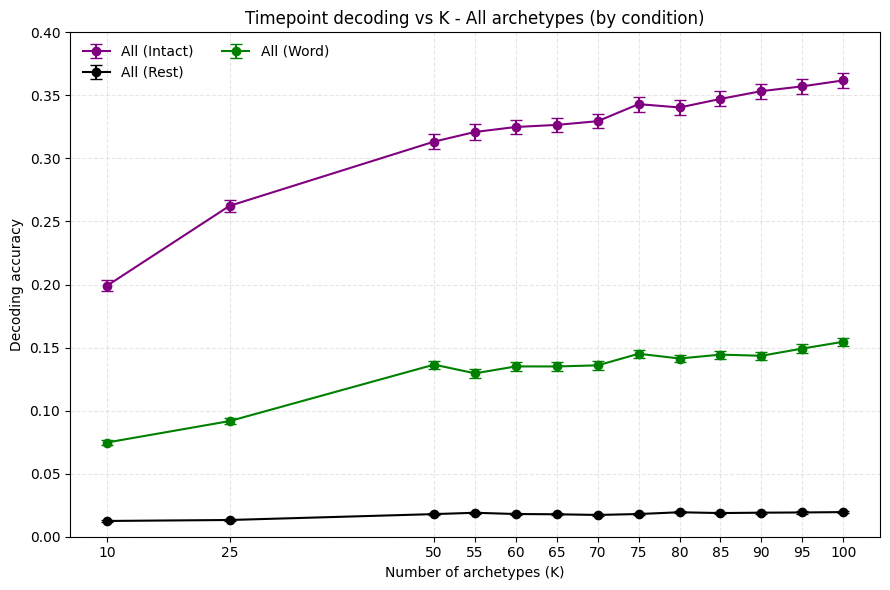

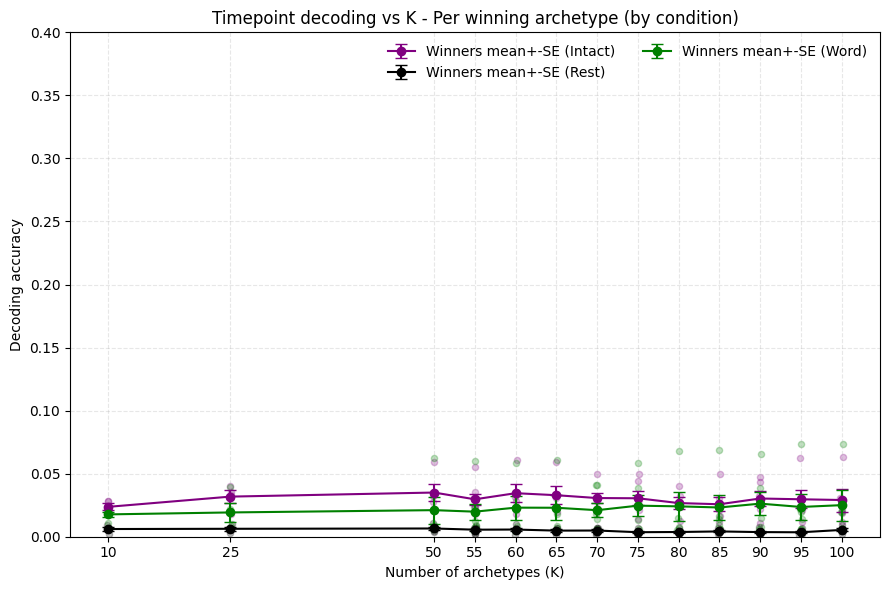

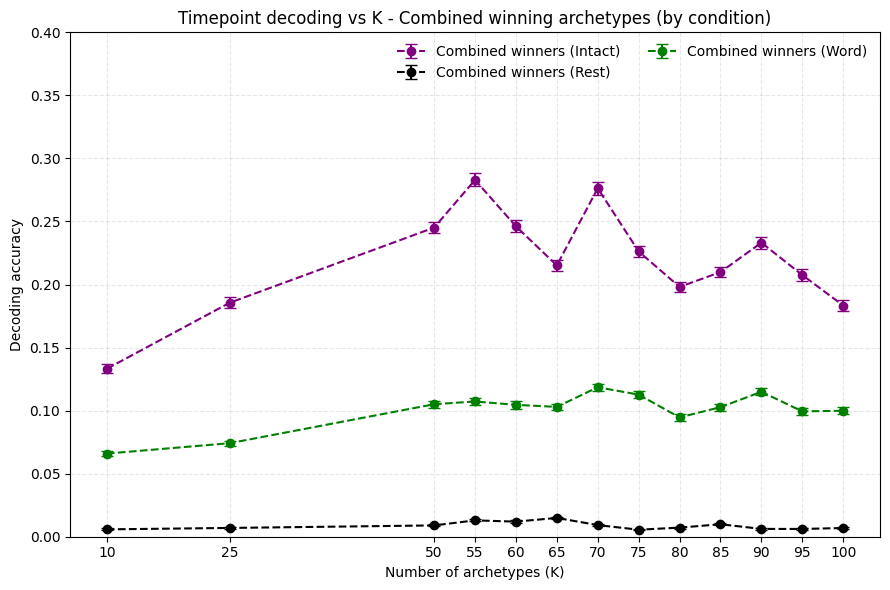

In [32]:
# ------------------ Example plots with y-axis control ------------------
YMIN, YMAX = 0.0, 0.4  # adjust as you like

plot_k_vs_accuracy_all_by_condition(
    decoding_df_full, K_LIST,
    y_min=YMIN, y_max=YMAX,
    save_path=os.path.join(PLOT_DIR, "k_vs_acc_all_by_condition.png")
)

plot_k_vs_accuracy_winners_by_condition(
    decoding_df_full, winners_byK, K_LIST,
    y_min=YMIN, y_max=YMAX,
    save_path=os.path.join(PLOT_DIR, "k_vs_acc_winners_by_condition.png")
)

plot_k_vs_accuracy_combined_winners_by_condition(
    decoding_df_full, K_LIST,
    y_min=YMIN, y_max=YMAX,
    save_path=os.path.join(PLOT_DIR, "k_vs_acc_combined_winners_by_condition.png")
)


In [33]:
intact_stack = prep_stack_for_decoding(intact_data_normalized) 
word_stack = prep_stack_for_decoding(word_data_normalized) 
rest_stack = prep_stack_for_decoding(rest_data_normalized)

In [34]:
intact_decode = run_timepoint_decoding_enhanced(intact_stack)
word_decode = run_timepoint_decoding_enhanced(word_stack)
rest_decode = run_timepoint_decoding_enhanced(rest_stack)

In [35]:
intact_acc = intact_decode['accuracy'].mean()
word_acc = word_decode['accuracy'].mean()
rest_acc = rest_decode['accuracy'].mean()

In [36]:
intact_acc

0.5236666666666666

In [37]:
word_acc

0.22600000000000003

In [38]:
rest_acc

0.027666666666666666